# <p style="text-align: center; color: red;"> Modelling and Control of Cement Emissions using ML</p> 

# <p style="text-align: left; color: yellow;"> Sheikh Junaid Fayaz -- M3RG Lab -- Indian Institute of Technology, Delhi</p> 
# <p style="text-align: left; color: yellow;"> Date : 06 March 2026</p> 

In [ ]:
import sys
sys.path.append('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks')
import functions  # First import
import importlib
importlib.reload(functions)  # Reload to reflect changes
from functions import *  # Now import updated functions

#add_custom_fonts(loc=".myfonts")
# import subprocess
# from shadow.plot import *
# from new_plot import * #This line is throwing an error #Solved by commenting out some of the keys of rcParams()

<module 'functions' from '/media/m3rg2000/mounted/Junaid/Heidelberg/Emissions/new_emission/Notebooks/functions.py'>

# Read data

In [6]:
filtered_palnt_b = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/filtered_plant_b_nox.pkl')
np.random.seed(1002)
random.seed(0)

X = filtered_palnt_b.iloc[:,1:]
y = filtered_palnt_b.iloc[:,[0]]

X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=100)

# All model training (CO)

### XGBoost works best

In [7]:
titles = ['Linear regression', 'Lasso', 'Ridge', 'Elastic net', 'Random forest', 'XGBoost', 'SVR', 'GPR', 'NN']

In [8]:
train_scores = []
val_scores = []
test_scores = []

# LR

LinearRegression()

Avg Training:  R^2 = 0.55, MAE = 40.67, MAPE = 14.87%
Avg Val:  R^2 = 0.54, MAE = 40.96, MAPE = 14.97%
Test 0.54 40.86 14.85


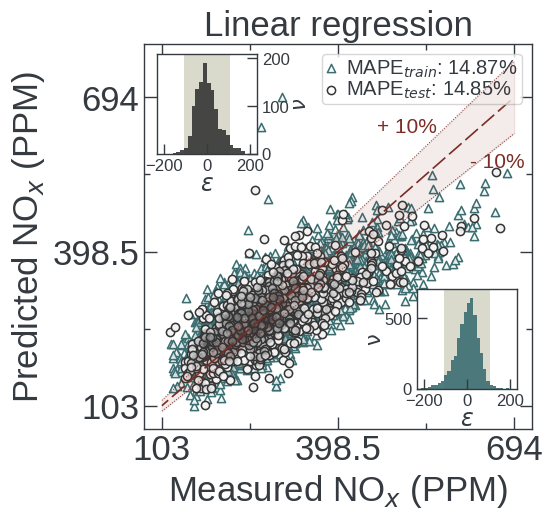

In [9]:
best_regressor = LinearRegression()
best_regressor.fit(X_train, y_train)

avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant2/{titles[0]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[0],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# Lasso

GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB
Fitting 1 folds for each of 4 candidates, totalling 4 fits
[CV] END ........................................alpha=1e-05; total time=   0.0s
[CV] END .......................................alpha=0.0001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s
GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 0.0401 s
System CPU time  : 0.0238 s
Total CPU time   : 0.0639 s
Wall clock time  : 0.5614 s

---- CPU Utilization Stats ----
Avg CPU usage    : 0.00%
Max CPU usage    : 0.00%
Logical cores    : 64
Physical cores   : 32


{'alpha': 0.0001}

Avg Training:  R^2 = 0.55, MAE = 40.67, MAPE = 14.87%
Avg Val:  R^2 = 0.54, MAE = 40.96, MAPE = 14.97%
Test 0.54 40.86 14.85


X has feature names, but Lasso was fitted without feature names
X has feature names, but Lasso was fitted without feature names
X has feature names, but Lasso was fitted without feature names


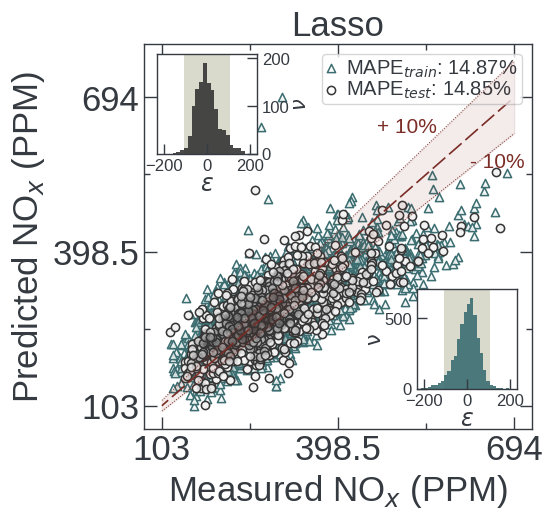

In [10]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = Lasso()
hyperparameter_grid= {'alpha': [0.00001, 0.0001,0.001, 0.1]} 
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
                                                       iterations = 4, verbose= 2)
end_profiling(save_path = None, note = None)
random_search.best_params_
# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path= None)
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant2/{titles[1]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[1],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

# Ridge

GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB
Fitting 1 folds for each of 4 candidates, totalling 4 fits
[CV] END ........................................alpha=1e-05; total time=   0.0s
[CV] END .......................................alpha=0.0001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s


{'alpha': 0.001}

GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 0.0252 s
System CPU time  : 0.0277 s
Total CPU time   : 0.0529 s
Wall clock time  : 0.5598 s

---- CPU Utilization Stats ----
Avg CPU usage    : 0.00%
Max CPU usage    : 0.00%
Logical cores    : 64
Physical cores   : 32
Avg Training:  R^2 = 0.55, MAE = 40.67, MAPE = 14.87%
Avg Val:  R^2 = 0.54, MAE = 40.96, MAPE = 14.97%
Test 0.54 40.86 14.85


X has feature names, but Ridge was fitted without feature names
X has feature names, but Ridge was fitted without feature names
X has feature names, but Ridge was fitted without feature names


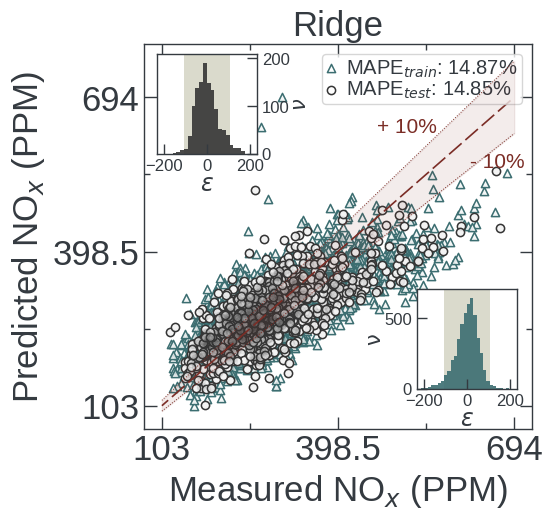

In [11]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = Ridge()
hyperparameter_grid= {'alpha': [0.00001, 0.0001,0.001, 0.1]} 
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
                                                       iterations = 4, verbose= 2)
random_search.best_params_
end_profiling(save_path = None, note = None)

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path= None)
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant2/{titles[2]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[2],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)  
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

# Elastic net

GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB
Fitting 1 folds for each of 4 candidates, totalling 4 fits
[CV] END ........................................alpha=1e-05; total time=   0.0s
[CV] END .......................................alpha=0.0001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s


{'alpha': 1e-05}

GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 243 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 0.0453 s
System CPU time  : 0.0201 s
Total CPU time   : 0.0655 s
Wall clock time  : 0.5622 s

---- CPU Utilization Stats ----
Avg CPU usage    : 0.00%
Max CPU usage    : 0.00%
Logical cores    : 64
Physical cores   : 32
Avg Training:  R^2 = 0.55, MAE = 40.69, MAPE = 14.89%
Avg Val:  R^2 = 0.54, MAE = 40.98, MAPE = 14.99%
Test 0.55 40.89 14.87


X has feature names, but ElasticNet was fitted without feature names
X has feature names, but ElasticNet was fitted without feature names
X has feature names, but ElasticNet was fitted without feature names


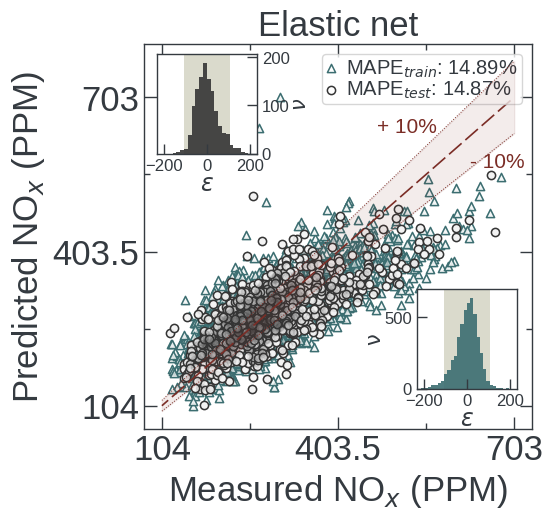

In [12]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = ElasticNet()
hyperparameter_grid= {'alpha': [0.00001, 0.0001,0.001, 0.1]} 
iterations = 4
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
                                                       iterations = 4, verbose= 2)
random_search.best_params_
end_profiling(save_path = None, note = None)

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path= None)
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant2/{titles[3]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[3],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# Random forest

GPU 0: Utilization: 0%, Memory Used: 268 MB / 12282 MB
Fitting 1 folds for each of 100 candidates, totalling 100 fits


{'n_estimators': 200,
 'min_samples_split': 4,
 'min_samples_leaf': 1,
 'max_features': 0.4,
 'max_depth': None,
 'ccp_alpha': 0.0,
 'bootstrap': False}

GPU 0: Utilization: 0%, Memory Used: 268 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 268 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 268 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 180.7182 s
System CPU time  : 19.2155 s
Total CPU time   : 199.9337 s
Wall clock time  : 116.7451 s

---- CPU Utilization Stats ----
Avg CPU usage    : 2.68%
Max CPU usage    : 33.31%
Logical cores    : 64
Physical cores   : 32


A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


Avg Training:  R^2 = 1.0, MAE = 1.5, MAPE = 0.54%
Avg Val:  R^2 = 0.76, MAE = 28.04, MAPE = 10.26%
Test 0.78 27.18 10.04


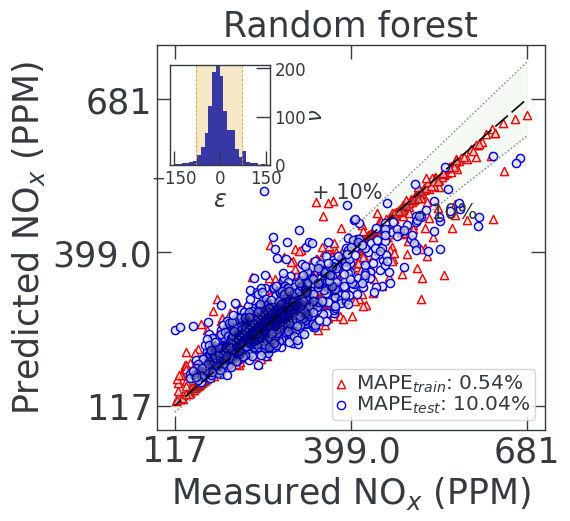

In [ ]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = RandomForestRegressor(random_state=42, n_jobs=-1)
hyperparameter_grid = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [12, 16, 20, 24, None],        # None = grow until pure
    "min_samples_split": [2, 4, 8, 16, 32],
    "min_samples_leaf": [1, 2, 4, 8, 12, 16],
    "max_features": [0.3, 0.4, 0.5, 0.6, "sqrt", "log2"],
    "ccp_alpha": [0.0, 0.0001, 0.0005, 0.001, 0.005],
    "bootstrap": [True, False]
}
iterations =100
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, np.ravel(y_train), # ravel for randomforest
                                                       iterations = iterations, verbose= 1)
random_search.best_params_
end_profiling(save_path = None, note = None)

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = 'palnt2 nox random forest',log_file_path= '/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant2/random_forest.txt')
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)  
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant2/{titles[4]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[4],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

RandomForestRegressor(ccp_alpha=0.0005, max_depth=24, max_features=0.6,
                      min_samples_leaf=4, min_samples_split=16,
                      n_estimators=1000, n_jobs=-1, random_state=42)

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


Avg Training:  R^2 = 0.87, MAE = 20.29, MAPE = 7.41%
Avg Val:  R^2 = 0.73, MAE = 30.41, MAPE = 11.14%
Test 0.76 28.72 10.61


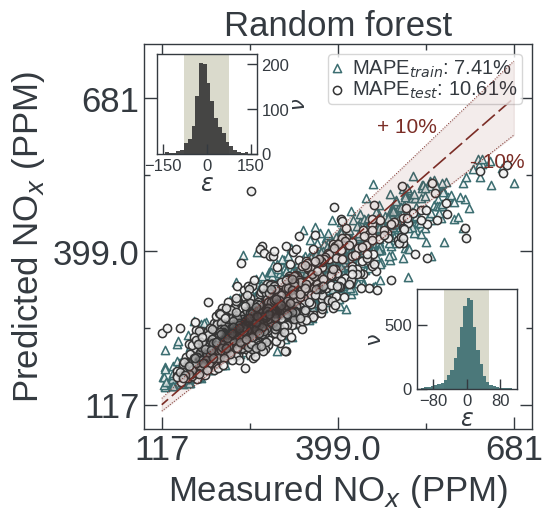

In [13]:
# best model overfit, this model is more genralizable model better
np.random.seed(1002)
random.seed(0)
best_regressor = RandomForestRegressor(random_state=42, n_jobs=-1,
n_estimators= 1000, min_samples_split= 16, min_samples_leaf= 4, max_features= 0.6, max_depth= 24, ccp_alpha= 0.0005, bootstrap= True
                                  )
best_regressor.fit(X_train, np.ravel(y_train))
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant2/{titles[4]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[4],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)  
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# XGboost

In [ ]:
# np.random.seed(1002)
# random.seed(0)

# start_profiling() 
# regressor = XGBRegressor(random_state=42, tree_method='gpu_hist', n_jobs=-1)
# hyperparameter_grid = {
#     "n_estimators": [200, 400, 600, 800],            # more trees but slower learning
#     "max_depth": [3, 4, 5, 6, 7],                   # shallower trees → less overfitting
#     "min_child_weight": [5, 7, 9, 11],               # larger = less complex splits
#     "subsample": [0.6, 0.7, 0.8, 0.9],               # row sampling
#     "colsample_bytree": [0.6, 0.7, 0.8, 0.9],        # feature sampling
#     "learning_rate": [0.01, 0.02, 0.03, 0.05],       # slower learning → needs more trees
#     "reg_lambda": [5, 7, 9, 11],                     # L2 regularization
#     "reg_alpha": [3, 5, 7, 9]                        # L1 regularization
# }
# iterations =100
# best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
#                                                        iterations = iterations, verbose= 2)
# random_search.best_params_
# end_profiling(save_path = None, note = None)

# # save Randomsearch results
# log_search_space(random_search.cv_results_, file_note = 'palnt2 CO XGBoost',log_file_path= '/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant2/XGboost.txt')
# # k fold cross validation
# avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)  fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant2/{titles[0]}_parity.pdf'
# # parity plot
# test_results = parity_train_test(best_regressor, titles[5],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)  train_scores.append(tuple(avg_train_results)) val_scores.append(tuple(avg_val_results)) test_scores.append(tuple(test_results))

Avg Training:  R^2 = 0.91, MAE = 17.41, MAPE = 6.26%
Avg Val:  R^2 = 0.76, MAE = 28.58, MAPE = 10.2%
Test 0.77 27.5 9.89


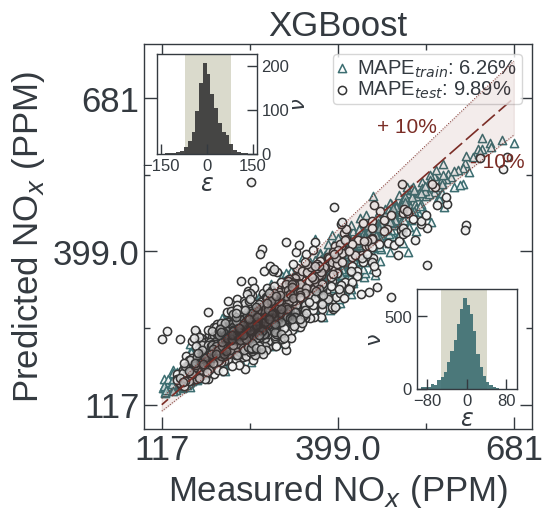

In [14]:
# best model overfit, iteration 76 is more genralizable model better
np.random.seed(1002)
random.seed(0)
best_regressor = load_model('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/nox/plant_2_nox.pkl')
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)  
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant2/{titles[5]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[5],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)  
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

# best model stats

In [9]:
np.random.seed(1002)
random.seed(0)
start_profiling() 

model_nox = XGBRegressor(
subsample=0.9, reg_lambda=1,
reg_alpha=1, n_estimators=200,
min_child_weight=7, max_depth=8,
learning_rate=0.02, colsample_bytree=0.9, n_jobs= -1

).fit(X_train,y_train)
train_test_score(model_nox, X_train, X_test, y_train, y_test)


end_profiling()

model_size('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/nox/plant_2_nox.pkl')

GPU 0: Utilization: 0%, Memory Used: 814 MB / 12282 MB
Training 0.91 17.98 6.48
Test 0.77 27.5 9.89
GPU 0: Utilization: 0%, Memory Used: 814 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 814 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 814 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 2.8755 s
System CPU time  : 0.0512 s
Total CPU time   : 2.9267 s
Wall clock time  : 3.0586 s

---- CPU Utilization Stats ----
Avg CPU usage    : 1.30%
Max CPU usage    : 1.56%
Logical cores    : 64
Physical cores   : 32
Model size: 1.26 MB


In [7]:
model_nox.get_params()

{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.9,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'gamma': None,
 'gpu_id': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.02,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 8,
 'max_leaves': None,
 'min_child_weight': 7,
 'missing': nan,
 'monotone_constraints': None,
 'n_estimators': 200,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'predictor': None,
 'random_state': None,
 'reg_alpha': 1,
 'reg_lambda': 1,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 0.9,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

# SVR

In [ ]:
np.random.seed(1002)
random.seed(0)
start_profiling() 

pipeline = Pipeline([      
    ('scaler_X', StandardScaler()), 
    ('model', TransformedTargetRegressor(
        regressor= SVR(),
        transformer=StandardScaler()))
])
hyperparameter_grid = {
    "kernel":  ["rbf", "poly", "sigmoid"],
    "C":       [0.1, 1, 10, 50, 100, 200, 500],
    "epsilon": [0.001, 0.01, 0.05, 0.1, 0.2, 0.5],
    "gamma":   ["scale", "auto", 1e-4, 1e-3, 1e-2, 1e-1],
    "degree":  [2, 3, 4],          
    "coef0":   [0.0, 0.1, 0.5, 1.0],
    "tol":     [1e-4, 1e-3, 1e-2],
    "shrinking": [True, False]
}

iterations = 200
best_regressor,random_search = RandomSearchCV_pipeline(pipeline, flatten_grid(hyperparameter_grid), X_train, y_train, 
                                                       iterations = iterations, verbose= 2)
random_search.best_params_
end_profiling(save_path = None,
              note = 'RandomSearchCV for plant 4 SVR')

# save_model(best_regressor,
#            model_path =f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant2/svr_best.pkl') # =None if not want to save

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path= "/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant2/svr.txt")
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant2/{titles[6]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[6],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

GPU 0: Utilization: 0%, Memory Used: 268 MB / 12282 MB
Fitting 1 folds for each of 200 candidates, totalling 200 fits
[CV] END model__regressor__C=100, model__regressor__coef0=1.0, model__regressor__degree=4, model__regressor__epsilon=0.01, model__regressor__gamma=0.001, model__regressor__kernel=sigmoid, model__regressor__shrinking=True, model__regressor__tol=0.01; total time=   1.1s
[CV] END model__regressor__C=1, model__regressor__coef0=1.0, model__regressor__degree=2, model__regressor__epsilon=0.2, model__regressor__gamma=0.1, model__regressor__kernel=sigmoid, model__regressor__shrinking=False, model__regressor__tol=0.01; total time=   1.0s
[CV] END model__regressor__C=1, model__regressor__coef0=0.5, model__regressor__degree=2, model__regressor__epsilon=0.2, model__regressor__gamma=auto, model__regressor__kernel=rbf, model__regressor__shrinking=False, model__regressor__tol=0.01; total time=   0.5s
[CV] END model__regressor__C=0.1, model__regressor__coef0=0.0, model__regressor__degre

Pipeline(steps=[('scaler_X', StandardScaler()),
                ('model',
                 TransformedTargetRegressor(regressor=SVR(C=150, coef0=0.5,
                                                          epsilon=0.2,
                                                          gamma=0.02,
                                                          shrinking=False,
                                                          tol=0.0001),
                                            transformer=StandardScaler()))])

Avg Training:  R^2 = 0.9, MAE = 18.75, MAPE = 7.0%
Avg Val:  R^2 = 0.76, MAE = 28.46, MAPE = 10.33%
Test 0.77 27.01 9.9


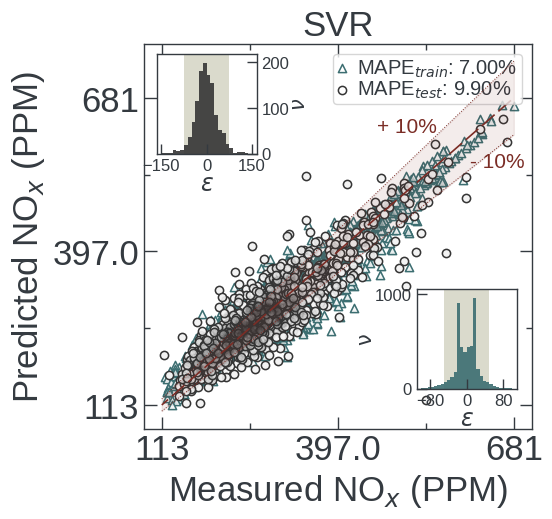

In [ ]:
# regressor = SVR(tol= 0.0001, shrinking= False, kernel= 'rbf', degree= 3, coef0= 0.5,epsilon= 0.2, gamma= 0.02,  C= 150)

# pipeline = Pipeline([      
#     ('scaler_X', StandardScaler()), 
#     ('model', TransformedTargetRegressor(
#         regressor= regressor,
#         transformer=StandardScaler()))
# ])
# pipeline.fit(X_train, y_train)

# save_model(pipeline,
#            model_path =f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant2/svr_best.pkl') # =None if not want to save
pipeline = load_model('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant2/svr_best.pkl')
avg_train_results, avg_val_results = k_fold_scores(pipeline, X_train, y_train) 
# train_test_score(pipeline, X_train, X_test, y_train, y_test)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant2/{titles[6]}_parity.pdf'
test_results = parity_train_test(pipeline, titles[6],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# GPR

In [ ]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
pipeline = Pipeline([      
    ('scaler_X', StandardScaler()), 
    ('model', TransformedTargetRegressor(
        regressor= GaussianProcessRegressor(random_state=3),
        transformer=StandardScaler()))
])
hyperparameter_grid = {
    "kernel": (
        # Matern + WhiteKernel
        [
            ConstantKernel(1.0, (1e-3, 1e3)) *
            Matern(length_scale=ls, nu=nu) +
            WhiteKernel(noise_level=noise)
            for ls in [0.1, 0.5, 1, 2, 5, 10]
            for nu in [0.5, 1.5, 2.5]
            for noise in [1e-5, 1e-3, 1e-1, 1]
        ]
        +
        # RBF + WhiteKernel
        [
            ConstantKernel(1.0, (1e-3, 1e3)) *
            RBF(length_scale=ls) +
            WhiteKernel(noise_level=noise)
            for ls in [0.1, 0.5, 1, 2, 5, 10]
            for noise in [1e-5, 1e-3, 1e-1, 1]
        ]
        +
        # RationalQuadratic + WhiteKernel
        [
            ConstantKernel(1.0, (1e-3, 1e3)) *
            RationalQuadratic(length_scale=ls, alpha=alpha) +
            WhiteKernel(noise_level=noise)
            for ls in [0.1, 0.5, 1, 2, 5, 10]
            for alpha in [0.1, 0.5, 1, 2]
            for noise in [1e-5, 1e-3, 1e-1, 1]
        ]
    ),
    "alpha": [1e-10, 1e-5, 1e-3, 1e-2, 1e-1, 1],
    "normalize_y": [True, False],
}

iterations = 100
best_regressor,random_search = RandomSearchCV_pipeline(pipeline, flatten_grid(hyperparameter_grid), X_train, y_train, 
                                                       iterations = iterations, verbose= 1)
random_search.best_params_
end_profiling(save_path = '/home/m3rg2000/Junaid_temporary/saved_data/Time_cpu_stats/plant2/gpr_rand_SearchCV.txt',
              note = 'RandomSearchCV for plant 2 gpr')

save_model(best_regressor,
           model_path = f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant2/gpr_best.pkl')

# save Randomsearch results
log_search_space(random_search.cv_results_ , file_note = None,log_file_path= "/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant2/gpr.txt")
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant2/{titles[7]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[7],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test, avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.


Pipeline(steps=[('scaler_X', StandardScaler()),
                ('model',
                 TransformedTargetRegressor(regressor=GaussianProcessRegressor(alpha=1,
                                                                               kernel=1**2 * RationalQuadratic(alpha=2, length_scale=5) + WhiteKernel(noise_level=0.1),
                                                                               normalize_y=True,
                                                                               random_state=3),
                                            transformer=StandardScaler()))])

The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.


Avg Training:  R^2 = 0.76, MAE = 30.06, MAPE = 11.08%
Avg Val:  R^2 = 0.71, MAE = 32.21, MAPE = 11.81%
Test 0.75 30.25 11.15


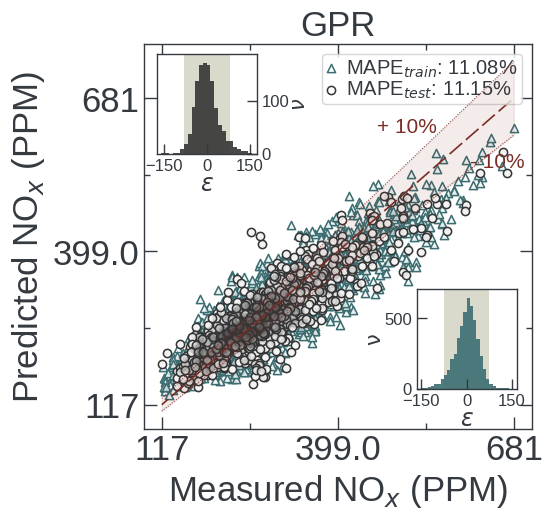

In [17]:
# Iteration 
np.random.seed(1002)
random.seed(0)

regressor = GaussianProcessRegressor(random_state = 3,
normalize_y= True, kernel=1**2 * RationalQuadratic(alpha=2, length_scale=5) + WhiteKernel(noise_level=0.1), alpha = 1)
pipeline = Pipeline([      
    ('scaler_X', StandardScaler()), 
    ('model', TransformedTargetRegressor(
        regressor= regressor,
        transformer=StandardScaler()))
])
pipeline.fit(X_train, y_train)
save_model(pipeline,
           model_path =f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant2/gpr_best.pkl') # =None if not want to save
# pipeline = load_model('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant2/svr_best.pkl')

# train_test_score(pipeline, X_train, X_test, y_train, y_test)
avg_train_results, avg_val_results = k_fold_scores(pipeline, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant2/{titles[7]}_parity.pdf'
test_results = parity_train_test(pipeline, titles[7],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test, avg_train_results,y, fig_path = fig_path)  
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

# NN

In [ ]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
pipeline = Pipeline([      
    ('scaler_X', StandardScaler()), 
    ('model', TransformedTargetRegressor(
        regressor= MLPRegressor(),
        transformer=StandardScaler()))
])
hyperparameter_grid = {
    'hidden_layer_sizes': [
        (64,), (128,), (256,),          # Single layer
        (64, 32), (128, 64), (256, 128), # Two layers
        (128, 64, 32), (64, 32, 16)      # Three layers (only for more data)
    ],
    'activation': ['relu'],
    'learning_rate_init': [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    'batch_size': [16, 32, 64, 128],
    'solver': ['adam'],  # 'lbfgs' works better for small datasets, 'adam' for large
    'early_stopping': [True],  # Keep fixed if you're using validation
    'n_iter_no_change': [20],
    'validation_fraction': [0.2],
    'max_iter': [500],
    'random_state': [42], 
    'verbose': [False]
}
iterations = 100
best_regressor,random_search = RandomSearchCV_pipeline(pipeline, flatten_grid(hyperparameter_grid), X_train, y_train,  # ravel for NN
                                                       iterations = iterations, verbose= 1)

random_search.best_params_
end_profiling(save_path = '/home/m3rg2000/Junaid_temporary/saved_data/Time_cpu_stats/plant2/NN_rand_SearchCV.txt',
              note = 'RandomSearchCV for plant 2 nn')
save_model(best_regressor,
           model_path = f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant2/NN_best.pkl')

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path = "/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant2/co_nn.txt")
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant2/{titles[8]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[8],'NO$_{x}$ (PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)  
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

Iteration 1, loss = 0.26287974
Validation score: 0.629768
Iteration 2, loss = 0.16253010
Validation score: 0.674967
Iteration 3, loss = 0.13809489
Validation score: 0.693666
Iteration 4, loss = 0.12950386
Validation score: 0.695609
Iteration 5, loss = 0.11370657
Validation score: 0.723062
Iteration 6, loss = 0.10521049
Validation score: 0.726696
Iteration 7, loss = 0.10127171
Validation score: 0.739248
Iteration 8, loss = 0.09930079
Validation score: 0.746069
Iteration 9, loss = 0.09476044
Validation score: 0.748926
Iteration 10, loss = 0.08915569
Validation score: 0.729315
Iteration 11, loss = 0.08512350
Validation score: 0.752996
Iteration 12, loss = 0.08606890
Validation score: 0.743180
Iteration 13, loss = 0.08311249
Validation score: 0.753527
Iteration 14, loss = 0.08383385
Validation score: 0.763625
Iteration 15, loss = 0.07798171
Validation score: 0.764785
Iteration 16, loss = 0.07497532
Validation score: 0.753982
Iteration 17, loss = 0.07352165
Validation score: 0.761453
Iterat

Pipeline(steps=[('scaler_X', StandardScaler()),
                ('model',
                 TransformedTargetRegressor(regressor=MLPRegressor(alpha=1e-05,
                                                                   batch_size=32,
                                                                   early_stopping=True,
                                                                   hidden_layer_sizes=(128,
                                                                                       64),
                                                                   max_iter=150,
                                                                   n_iter_no_change=20,
                                                                   random_state=42,
                                                                   validation_fraction=0.2,
                                                                   verbose=True),
                                            transformer=StandardScaler()))])

Iteration 1, loss = 0.28620641
Validation score: 0.589962
Iteration 2, loss = 0.16746201
Validation score: 0.663269
Iteration 3, loss = 0.14215798
Validation score: 0.667917
Iteration 4, loss = 0.12970548
Validation score: 0.698150
Iteration 5, loss = 0.12313868
Validation score: 0.700212
Iteration 6, loss = 0.11159976
Validation score: 0.714320
Iteration 7, loss = 0.10556496
Validation score: 0.724621
Iteration 8, loss = 0.10229517
Validation score: 0.736827
Iteration 9, loss = 0.09575195
Validation score: 0.743667
Iteration 10, loss = 0.09098070
Validation score: 0.754028
Iteration 11, loss = 0.08858764
Validation score: 0.757295
Iteration 12, loss = 0.08504224
Validation score: 0.757666
Iteration 13, loss = 0.07913526
Validation score: 0.744913
Iteration 14, loss = 0.08032852
Validation score: 0.761350
Iteration 15, loss = 0.07671854
Validation score: 0.756586
Iteration 16, loss = 0.07486310
Validation score: 0.767088
Iteration 17, loss = 0.06930308
Validation score: 0.751461
Iterat

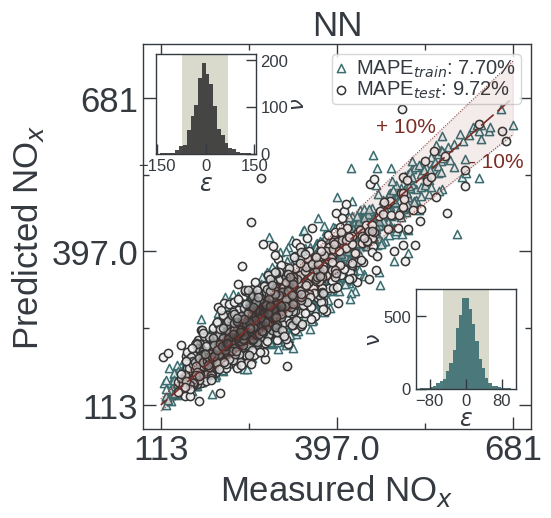

In [18]:
# Iteration 
np.random.seed(1002)
random.seed(0)

regressor = MLPRegressor(
verbose= True, validation_fraction= 0.2, solver= "adam", random_state= 42, early_stopping= True, n_iter_no_change= 20,activation= "relu", batch_size= 32, max_iter= 150,
learning_rate_init= 0.001, hidden_layer_sizes= (128, 64), alpha= 0.00001 #(64,32, 16)
)
pipeline = Pipeline([      
    ('scaler_X', StandardScaler()), 
    ('model', TransformedTargetRegressor(
        regressor= regressor,
        transformer=StandardScaler()))
])
pipeline.fit(X_train, y_train)
avg_train_results, avg_val_results = k_fold_scores(pipeline, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant2/{titles[8]}_parity.pdf'
test_results = parity_train_test(pipeline, titles[8],'NO$_{x}$', X_train, X_test, y_train, y_test, avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

In [20]:
train_sc = [(0.55, 40.67, 14.87),
 (0.55, 40.67, 14.87),
 (0.55, 40.67, 14.87),
 (0.55, 40.69, 14.89),
 (0.87, 20.29, 7.41),
 (0.91, 17.41, 6.26),
 (0.9, 18.75, 7.0),
 (0.76, 30.06, 11.08),
 (0.88, 20.63, 7.7)]

val_sc = [(0.54, 40.96, 14.97),
 (0.54, 40.96, 14.97),
 (0.54, 40.96, 14.97),
 (0.54, 40.98, 14.99),
 (0.73, 30.41, 11.14),
 (0.76, 28.58, 10.2),
 (0.76, 28.46, 10.33),
 (0.71, 32.21, 11.81),
 (0.75, 29.15, 10.64)]

test_sc = [(0.54, 40.86, 14.85),
 (0.54, 40.86, 14.85),
 (0.54, 40.86, 14.85),
 (0.55, 40.89, 14.87),
 (0.76, 28.72, 10.61),
 (0.77, 27.5, 9.89),
 (0.77, 27.01, 9.9),
 (0.75, 30.25, 11.15),
 (0.8, 26.28, 9.72)]

with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant2_train.pkl", "wb") as f:  
    pickle.dump(train_sc, f)
    
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant2_val.pkl", "wb") as f:  
    pickle.dump(val_sc, f)
    
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant2_test.pkl", "wb") as f:  
    pickle.dump(test_sc, f)
